In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

# --- Load the Excel file ---
df_a = pd.read_excel("Attitute towards AI.xlsx")
# Ensure quotes are string
df_a['Topic Quote'] = df_a['Topic Quote'].astype(str)


# Calculate sentiment for each quote
df_a['Sentiment'] = df_a['Topic Quote'].apply(lambda x: TextBlob(x).sentiment.polarity)


In [5]:
import pandas as pd
import numpy as np
from textblob import TextBlob
from scipy.stats import ttest_1samp, kruskal
import scikit_posthocs as sp
import statsmodels.stats.multitest as smm

# -----------------------------
# 1. Load data and compute sentiment
# -----------------------------
df = pd.read_excel("Attitute towards AI.xlsx")

df['Topic Quote'] = df['Topic Quote'].astype(str)
df['Sentiment'] = df['Topic Quote'].apply(lambda x: TextBlob(x).sentiment.polarity)

# -----------------------------
# 2. Aggregate sentiment by Category (L1)
# -----------------------------
cat = df.groupby("Category - L1")['Sentiment']

summary = cat.agg(['mean', 'std', 'count']).reset_index()
summary.columns = ['Category', 'Mean', 'SD', 'N']

print("\n=== Category Sentiment Summary ===")
print(summary)


# --------------------------------------------------
# 3. ONE-SAMPLE T-TEST (Is each category ≠ neutral 0?)
# --------------------------------------------------
ttest_results = []

for category, scores in cat:
    scores = np.array(scores)
    t_stat, p_val = ttest_1samp(scores, 0)   # test against neutral
    ttest_results.append([category, t_stat, p_val, len(scores)])

ttest_df = pd.DataFrame(ttest_results,
                        columns=["Category", "t-statistic", "p-value", "N"])

# FDR correction (Benjamini–Hochberg)
ttest_df["p-value-FDR"] = smm.multipletests(ttest_df["p-value"],
                                            method='fdr_bh')[1]

print("\n=== One-sample t-tests vs neutral (0) ===")
print(ttest_df)


# --------------------------------------------------
# 4. KRUSKAL–WALLIS TEST (overall difference)
# --------------------------------------------------
groups = [scores.values for _, scores in cat]
kruskal_stat, kruskal_p = kruskal(*groups)

print("\n=== Kruskal–Wallis Test Across Categories ===")
print(f"H = {kruskal_stat:.4f}, p = {kruskal_p:.4f}")


# --------------------------------------------------
# 5. DUNN POST-HOC TEST (pairwise comparisons)
# --------------------------------------------------
dunn = sp.posthoc_dunn(df, val_col='Sentiment',
                       group_col='Category - L1',
                       p_adjust='fdr_bh')

print("\n=== Dunn Pairwise Post-hoc Tests (FDR-corrected) ===")
print(dunn)



=== Category Sentiment Summary ===
                Category      Mean        SD   N
0               Personal  0.294659  0.235193   8
1   Professional - After  0.117192  0.202339  22
2  Professional - Before  0.095544  0.215546  14

=== One-sample t-tests vs neutral (0) ===
                Category  t-statistic   p-value   N  p-value-FDR
0               Personal     3.543562  0.009425   8     0.019386
1   Professional - After     2.716631  0.012924  22     0.019386
2  Professional - Before     1.658549  0.121126  14     0.121126

=== Kruskal–Wallis Test Across Categories ===
H = 4.2335, p = 0.1204

=== Dunn Pairwise Post-hoc Tests (FDR-corrected) ===
                       Personal  Professional - After  Professional - Before
Personal               1.000000              0.139296               0.131709
Professional - After   0.139296              1.000000               0.560016
Professional - Before  0.131709              0.560016               1.000000


In [6]:
from scipy.stats import mannwhitneyu, kruskal
import statsmodels.stats.multitest as smm
import pandas as pd

# --------------------------------------------------
# PREPARE GROUPS
# --------------------------------------------------
# Assumes df_a already has:
#   - Sentiment column
#   - Category - L1 column with three values:
#       Personal, Professional - Before, Professional - After

categories = df_a['Category - L1'].unique()

# Extract sentiment arrays per category
group_data = {cat: df_a[df_a['Category - L1'] == cat]['Sentiment'].values
              for cat in categories}

# --------------------------------------------------
# 1. PAIRWISE MANN–WHITNEY U TESTS (non-parametric)
# --------------------------------------------------
pairwise_results = []

for i, cat1 in enumerate(categories):
    for cat2 in categories[i+1:]:
        u_stat, p_val = mannwhitneyu(group_data[cat1],
                                     group_data[cat2],
                                     alternative='two-sided')
        pairwise_results.append([cat1, cat2, u_stat, p_val])

pairwise_df = pd.DataFrame(pairwise_results,
                           columns=['Category 1', 'Category 2',
                                    'U statistic', 'p-value'])

# FDR correction
pairwise_df['p-value (FDR)'] = smm.multipletests(pairwise_df['p-value'],
                                                 method='fdr_bh')[1]

print("\n=== Pairwise Mann–Whitney U Tests (with FDR) ===")
print(pairwise_df.to_string(index=False))

# --------------------------------------------------
# 2. OVERALL KRUSKAL–WALLIS TEST (all three groups)
# --------------------------------------------------
groups = [group_data[cat] for cat in categories]
kw_stat, kw_p = kruskal(*groups)

print("\n=== Kruskal–Wallis Test Across All Categories ===")
print(f"H = {kw_stat:.4f}, p = {kw_p:.4f}")



=== Pairwise Mann–Whitney U Tests (with FDR) ===
           Category 1           Category 2  U statistic  p-value  p-value (FDR)
Professional - Before Professional - After        132.5 0.489287       0.489287
Professional - Before             Personal         31.0 0.089083       0.133624
 Professional - After             Personal         49.0 0.068289       0.133624

=== Kruskal–Wallis Test Across All Categories ===
H = 4.2335, p = 0.1204


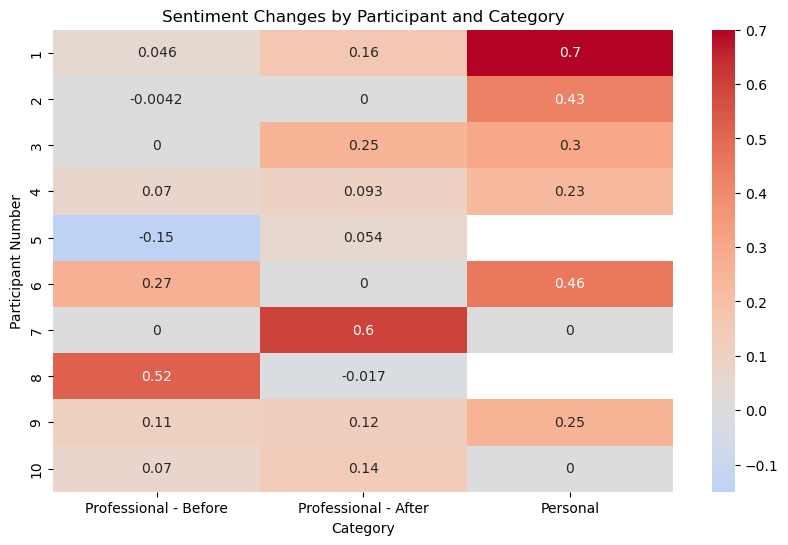

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_sentiment.set_index('Participant Number')[['Professional - Before','Professional - After','Personal']],
    annot=True, cmap='coolwarm', center=0
)
plt.title("Sentiment Changes by Participant and Category")
plt.show()


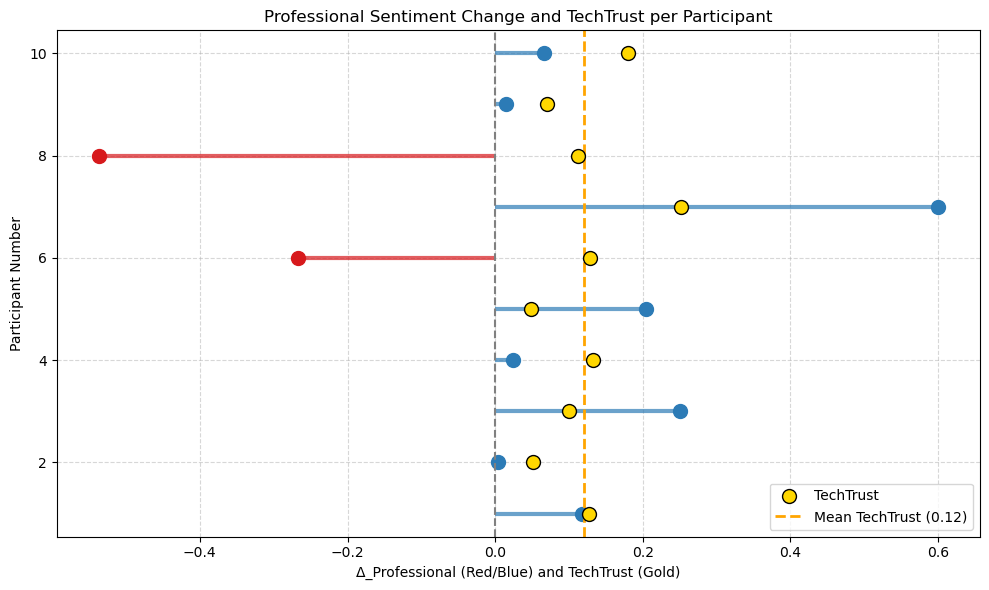

In [14]:
import matplotlib.pyplot as plt

# Sort data for clarity
data_sorted = data.sort_values('Δ_Professional', ascending=True)

# Compute mean TechTrust
mean_techtrust = data_sorted['TechTrust'].mean()

plt.figure(figsize=(10,6))

# -----------------------------
# Lollipop for Δ_Professional (loop to color each point)
# -----------------------------
for i, row in data_sorted.iterrows():
    color = '#d7191c' if row['Δ_Professional'] < 0 else '#2c7bb6'
    # horizontal line
    plt.hlines(y=row['Participant Number'], xmin=0, xmax=row['Δ_Professional'], color=color, alpha=0.7, linewidth=3)
    # dot at the end of line
    plt.plot(row['Δ_Professional'], row['Participant Number'], 'o', color=color, markersize=10)

# -----------------------------
# Overlay TechTrust as golden points
# -----------------------------
plt.scatter(data_sorted['TechTrust'], data_sorted['Participant Number'],
            color='gold', edgecolor='black', s=100, zorder=5, label='TechTrust')

# -----------------------------
# Add mean TechTrust vertical line
# -----------------------------
plt.axvline(mean_techtrust, color='orange', linestyle='--', linewidth=2, label=f"Mean TechTrust ({mean_techtrust:.2f})")

# -----------------------------
# Formatting
# -----------------------------
plt.axvline(0, color='grey', linestyle='--')
plt.xlabel("Δ_Professional (Red/Blue) and TechTrust (Gold)")
plt.ylabel("Participant Number")
plt.title("Professional Sentiment Change and TechTrust per Participant")
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



In [17]:
from scipy.stats import shapiro, normaltest

for col in variables:
    print(f"\n{col} Normality Tests:")
    
    # Shapiro-Wilk
    stat, p = shapiro(data[col].dropna())
    print(f"Shapiro-Wilk: W={stat:.3f}, p={p:.3f} {'(not normal)' if p<0.05 else '(normal)'}")
    
    # D’Agostino’s K^2
    stat, p = normaltest(data[col].dropna())
    print(f"D'Agostino K^2: stat={stat:.3f}, p={p:.3f} {'(not normal)' if p<0.05 else '(normal)'}")



Professional - Before Normality Tests:
Shapiro-Wilk: W=0.848, p=0.055 (normal)
D'Agostino K^2: stat=8.130, p=0.017 (not normal)

Professional - After Normality Tests:
Shapiro-Wilk: W=0.781, p=0.009 (not normal)
D'Agostino K^2: stat=14.039, p=0.001 (not normal)

Personal Normality Tests:
Shapiro-Wilk: W=0.945, p=0.661 (normal)
D'Agostino K^2: stat=0.192, p=0.908 (normal)

TechTrust Normality Tests:
Shapiro-Wilk: W=0.912, p=0.292 (normal)
D'Agostino K^2: stat=3.412, p=0.182 (normal)


/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=8 observations were given.
  return hypotest_fun_in(*args, **kwds)


=== Pearson Correlations with TechTrust ===
Professional - Before vs TechTrust: r = 0.087, p = 0.811
Professional - After vs TechTrust: r = 0.742, p = 0.014
Personal vs TechTrust: r = -0.276, p = 0.439

=== Spearman Correlations with TechTrust ===
Professional - Before vs TechTrust: rho = 0.354, p = 0.316
Professional - After vs TechTrust: rho = 0.413, p = 0.235
Personal vs TechTrust: rho = -0.188, p = 0.604


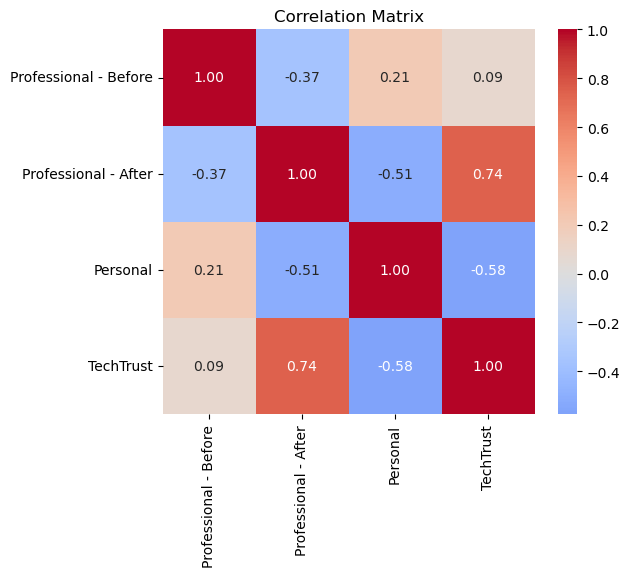

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Select relevant columns
cols = ['Professional - Before', 'Professional - After', 'Personal', 'TechTrust']
corr_data = data[cols].copy()

# -----------------------------
# 1. Compute Pearson correlations
# -----------------------------
print("=== Pearson Correlations with TechTrust ===")
for col in ['Professional - Before', 'Professional - After', 'Personal']:
    corr, pval = pearsonr(corr_data[col].fillna(0), corr_data['TechTrust'])
    print(f"{col} vs TechTrust: r = {corr:.3f}, p = {pval:.3f}")

# -----------------------------
# 2. Compute Spearman correlations
# -----------------------------
print("\n=== Spearman Correlations with TechTrust ===")
for col in ['Professional - Before', 'Professional - After', 'Personal']:
    corr, pval = spearmanr(corr_data[col].fillna(0), corr_data['TechTrust'])
    print(f"{col} vs TechTrust: rho = {corr:.3f}, p = {pval:.3f}")

# -----------------------------
# 3. Optional: Correlation heatmap
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(corr_data.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()
